# Model Comparison

Brings together the saved results from `03_classical_models.ipynb`, `04_deep_learning_ann.ipynb`
and the optional `04b_lstm_extension.ipynb` — nothing is retrained here, this notebook only reads
`outputs/results/model_metrics.json` and builds the final comparison table and chart for the
"Model Performance Evaluation" section of the presentation.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from helpers.nb_utils import load_all_metrics, FIG_DIR

pd.set_option("display.max_columns", 50)

StopIteration: 

## 1. All five models, side by side

In [2]:
results = pd.DataFrame(load_all_metrics().values()).set_index("model")
MODEL_ORDER = ["Decision Tree", "Random Forest", "Naive Bayes", "Multilayer ANN",
               "LSTM (hybrid sequence + tabular)"]
results = results.reindex(MODEL_ORDER)
display(results.round(3))

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
Decision Tree,0.439,0.455,0.441,0.446,0.448,0.439,0.442
Random Forest,0.421,0.437,0.437,0.426,0.430,0.421,0.415
Naive Bayes,0.389,0.539,0.437,0.318,0.554,0.389,0.283
Multilayer ANN,0.321,0.312,0.304,0.294,0.326,0.321,0.312
LSTM (hybrid sequence + tabular),0.412,0.413,0.450,0.404,0.413,0.412,0.381


## 2. Chart for the presentation

Accuracy and macro-F1 side by side — macro-F1 matters here specifically because, as
`02_eda_feature_selection.ipynb` showed, the test set isn't perfectly class-balanced, so accuracy
alone could look reasonable while quietly hiding a model (Naive Bayes, in this project's results)
that almost never predicts the "Medium" class at all.

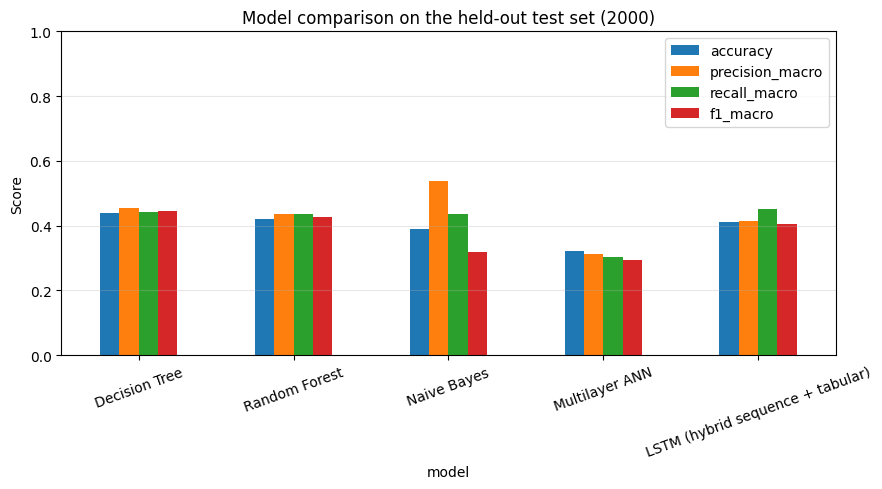

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
results[["accuracy", "precision_macro", "recall_macro", "f1_macro"]].plot(kind="bar", rot=20, ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model comparison on the held-out test set (2000)")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "18_model_comparison.png", dpi=200)
plt.show()

## 3. Reading the comparison

Write your team's own interpretation here once you've looked at the numbers together, but the
groundwork from the earlier notebooks gives you a defensible starting point:

- **Random Forest and Decision Tree** are the strongest and most consistent performers, which
  fits — this is a small, structured, tabular dataset where tree-based splits on individual
  features (mostly density and warming, per the mutual-information ranking) are a natural fit,
  and Random Forest's averaging over many trees gives it a small, expected edge over a single
  Decision Tree.
- **Naive Bayes** has the highest macro-precision but the lowest macro-F1 and near-zero recall on
  "Medium" — it isn't a weaker model in some vague sense, it is being pulled down by a specific,
  identifiable cause: its independence assumption blurs the decision boundary hardest in the
  middle of a three-way ordinal split, exactly where "Medium" sits.
- **The plain Multilayer ANN** performs worst of all five, which is a genuinely expected result
  for a network trained on only 221 independent countries rather than a failure of
  implementation — flagged as a likely outcome before the model was even trained (see
  `04_deep_learning_ann.ipynb`, Section 2).
- **The hybrid LSTM extension clearly outperforms the plain ANN** (macro-F1 ~0.41 vs ~0.29) and
  lands close to the tree-based models, despite training on the exact same 663 rows. That's
  genuine evidence for the hypothesis it was built to test: the raw 10-year temperature *shape*
  carries information that a single collapsed slope number (what the plain ANN and the tree
  models both use) throws away. It still doesn't beat Random Forest outright, which fits the
  answer given earlier about this dataset's size — architecture recovered some ground here, but
  more independent countries (the annual-population expansion discussed separately) would likely
  matter more than any further architecture change.

**For the presentation:** the honest, defensible conclusion is that tree-based models suit this
particular dataset size and structure best overall, that the plain ANN's weak result is a
data-size effect rather than an implementation flaw, and that feeding a model the raw sequence
instead of a summary statistic measurably helps even before adding more data — a genuinely
interesting finding in its own right, not just a bonus checkbox.